In [2]:
import pandas as pd
from src.data import DATA_DIR_INTERIM, DATA_DIR_PROCESSED

from topic_gen.evaluate.io import read_irds_topics
from src.io import load_topics_from_path, read_metadata
from topic_gen.evaluate import MetaExperiment, Experiment
from topic_gen.evaluate.measures_agreement import JaccardIndex, BertScore, RelativeLength, CosineSimilarity

In [10]:
BASE_DIR = DATA_DIR_INTERIM / "dl19" / "topics-dl19"

In [11]:
experiments = load_topics_from_path(BASE_DIR)
baseline = Experiment(topics=read_irds_topics("msmarco-passage/trec-dl-2019/judged"))

In [14]:
meta_exp = MetaExperiment(
    experiments=experiments,
    baseline=baseline,
    measures=[JaccardIndex(), BertScore(), RelativeLength(),
              CosineSimilarity()],
    filter_topics=True,
)

In [15]:
res = meta_exp.evaluate()

[topic_gen] [WARNING] (utils.py:116) Missing topics in exp: {'182539'}
[topic_gen] [WARNING] (utils.py:116) Missing topics in exp: {'359349'}


OutOfMemoryError: CUDA out of memory. Tried to allocate 60.00 MiB. GPU 0 has a total capacity of 47.40 GiB of which 60.38 MiB is free. Process 2754615 has 42.76 GiB memory in use. Process 2785393 has 4.56 GiB memory in use. Of the allocated memory 3.85 GiB is allocated by PyTorch, and 409.94 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [7]:
# results = TopicEvaluator.experiment(
#     predictions=predictions,
#     reference=reference,
#     measures=[CosineSimilarity(), BertScore(), JaccardIndex(), RelativeLength()],
#     names=names)
df = pd.DataFrame(res)
# df.to_csv(DATA_DIR_PROCESSED / "topic_evaluation_robust-2.csv.gz", index=False, compression="gzip")

In [9]:
res

[]

## Table

In [8]:
df = pd.read_csv(DATA_DIR_PROCESSED / "topic_evaluation_robust-2.csv.gz")

In [9]:
metadata = read_metadata(BASE_DIR)

[topic_gen] [WARNING] (io.py:45) Metadata not found for result 2025-12-01_07:07:25, skipping...


In [11]:
missing = (df[["name", "missing"]].drop_duplicates(
).set_index("name").to_dict()["missing"])
df = df.pivot(index=["name"], columns="measure", values="value").reset_index()
df["missing"] = df["name"].map(missing)
df = df.merge(metadata, left_on="name", right_on='date')

In [12]:
df[["model", "prompt", "nqueries", "ndocspos", "ndocsneg", "CosineSimilarity(title)", "BertScore(title)", "JaccardIndex(title)", "RelativeLength(title)",
    "CosineSimilarity(description)", "BertScore(description)", "JaccardIndex(description)", "RelativeLength(description)",
    "CosineSimilarity(narrative)", "BertScore(narrative)", "JaccardIndex(narrative)", "RelativeLength(narrative)"]]

,model,prompt,nqueries,ndocspos,ndocsneg,CosineSimilarity(title),BertScore(title),JaccardIndex(title),RelativeLength(title),CosineSimilarity(description),BertScore(description),JaccardIndex(description),RelativeLength(description),CosineSimilarity(narrative),BertScore(narrative),JaccardIndex(narrative),RelativeLength(narrative)
0,qwen3-30B-no-think,topic-query,1,0,0,0.811510,0.732312,0.411492,1.126359,0.774290,0.703996,0.205340,1.257297,0.663549,0.547062,0.099931,2.390539
1,qwen3-30B-no-think,topic-query,3,0,0,0.790550,0.720679,0.376507,1.204439,0.791652,0.711159,0.213656,1.418585,0.673041,0.550086,0.104275,2.538525
2,qwen3-30B-no-think,topic-query,5,0,0,0.780949,0.712319,0.356327,1.241484,0.791098,0.703346,0.207305,1.567608,0.680211,0.552026,0.103916,2.636150
3,qwen3-30B-no-think,topic-query,7,0,0,0.780041,0.708803,0.361585,1.271963,0.788003,0.700654,0.203731,1.664643,0.675895,0.550416,0.106505,2.704843
4,qwen3-30B-no-think,topic-docs-pos,0,1,0,0.348263,0.559055,0.062577,1.341262,0.393217,0.595408,0.090852,1.840951,0.408130,0.507336,0.071523,3.305615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,gpt-oss-120B-ollama,topic-query-contrastive,1,1,1,0.813836,0.740491,0.412836,1.081052,0.775571,0.700177,0.197605,1.211563,0.685409,0.566024,0.124222,2.508718
196,gpt-oss-120B-ollama,topic-query-contrastive,1,2,2,0.829056,0.751601,0.436761,1.082109,0.780825,0.700543,0.193715,1.243998,0.693240,0.566375,0.122521,2.647568
197,gpt-oss-120B-ollama,topic-query-contrastive,1,3,3,0.815795,0.739422,0.416935,1.074606,0.772383,0.697173,0.187039,1.268892,0.692094,0.562371,0.119016,2.797136
198,gpt-oss-120B-ollama,topic-query-contrastive,1,4,4,0.822996,0.747985,0.428802,1.098623,0.777913,0.694270,0.183982,1.323295,0.690129,0.562944,0.118270,2.909975


### Plot

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv(DATA_DIR_PROCESSED / "topic_evaluation_robust-2.csv.gz")

In [24]:
df = df.merge(metadata, left_on="name", right_on="date")[
    ["measure", "value", "model", "prompt", "nqueries", "ndocspos", "ndocsneg"]]

In [25]:
df["component"] = df["measure"].apply(lambda x: x.split("(")[1].rstrip(")"))
df["measure_name"] = df["measure"].apply(lambda x: x.split("(")[0])

In [26]:
col_order = ["title", "description", "narrative"]
y_mins = {
    "CosineSimilarity": 0.6,
    "BertScore": 0.5,
    "JaccardIndex": 0.5}
models = df["model"].unique()
colors = sns.color_palette("tab10", len(models))
model_colors = dict(zip(models, colors))

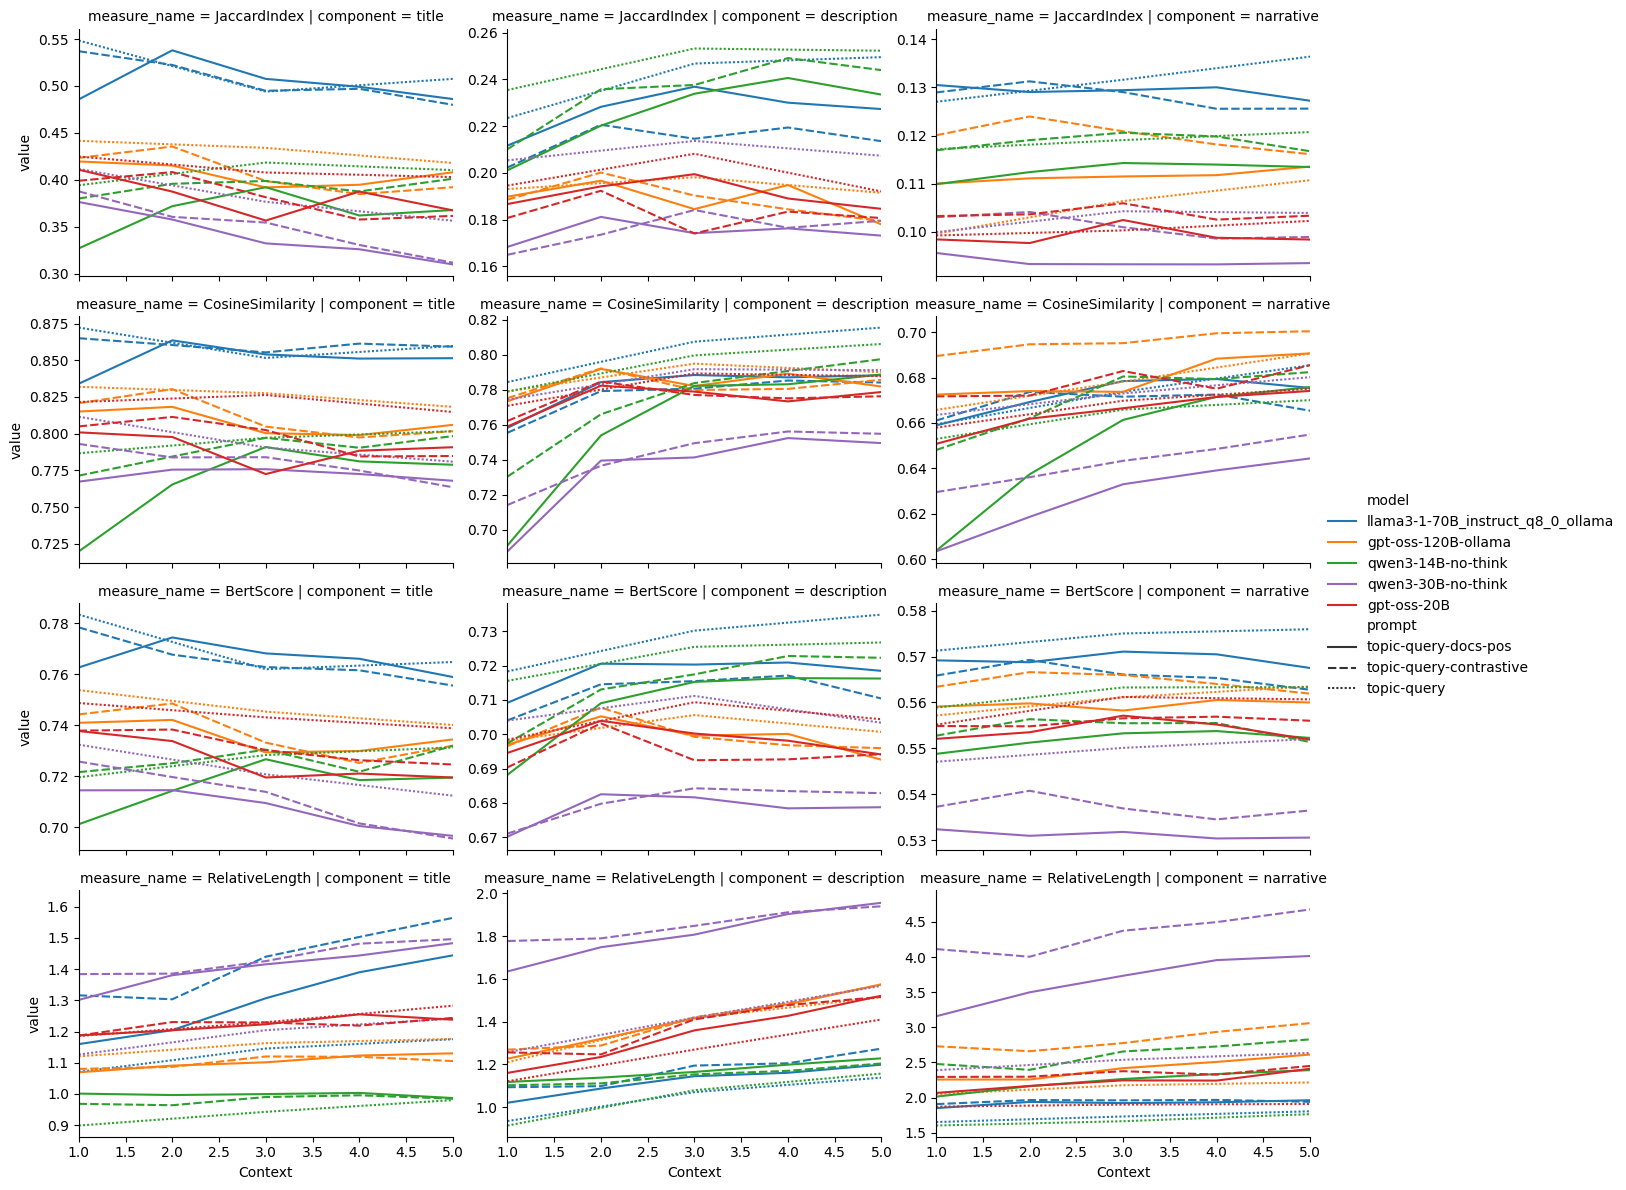

In [35]:
g = sns.relplot(
    data=df[df["prompt"].isin(
        ["topic-query-docs-pos", "topics-query-docs-neg", "topic-query-contrastive", 'topic-query'])],
    x="nqueries",
    y="value",
    hue="model",
    style="prompt",
    row="measure_name",
    row_order=["JaccardIndex", "CosineSimilarity", "BertScore", "RelativeLength"],
    col="component",
    col_order=col_order,
    kind="line",
    height=3,
    palette=model_colors,
    aspect=1.5,
    facet_kws={"sharey": False},
)

for ax in g.axes.flatten():
    ax.set_xbound(1,5)
    ax.set_xlabel("Context")
#     title = ax.get_title()
#     measure = title.split(" = ")[1].replace(" | field", "")
#     if measure in y_mins:
#         ax.set_ylim(bottom=y_mins[measure])


plt.show()

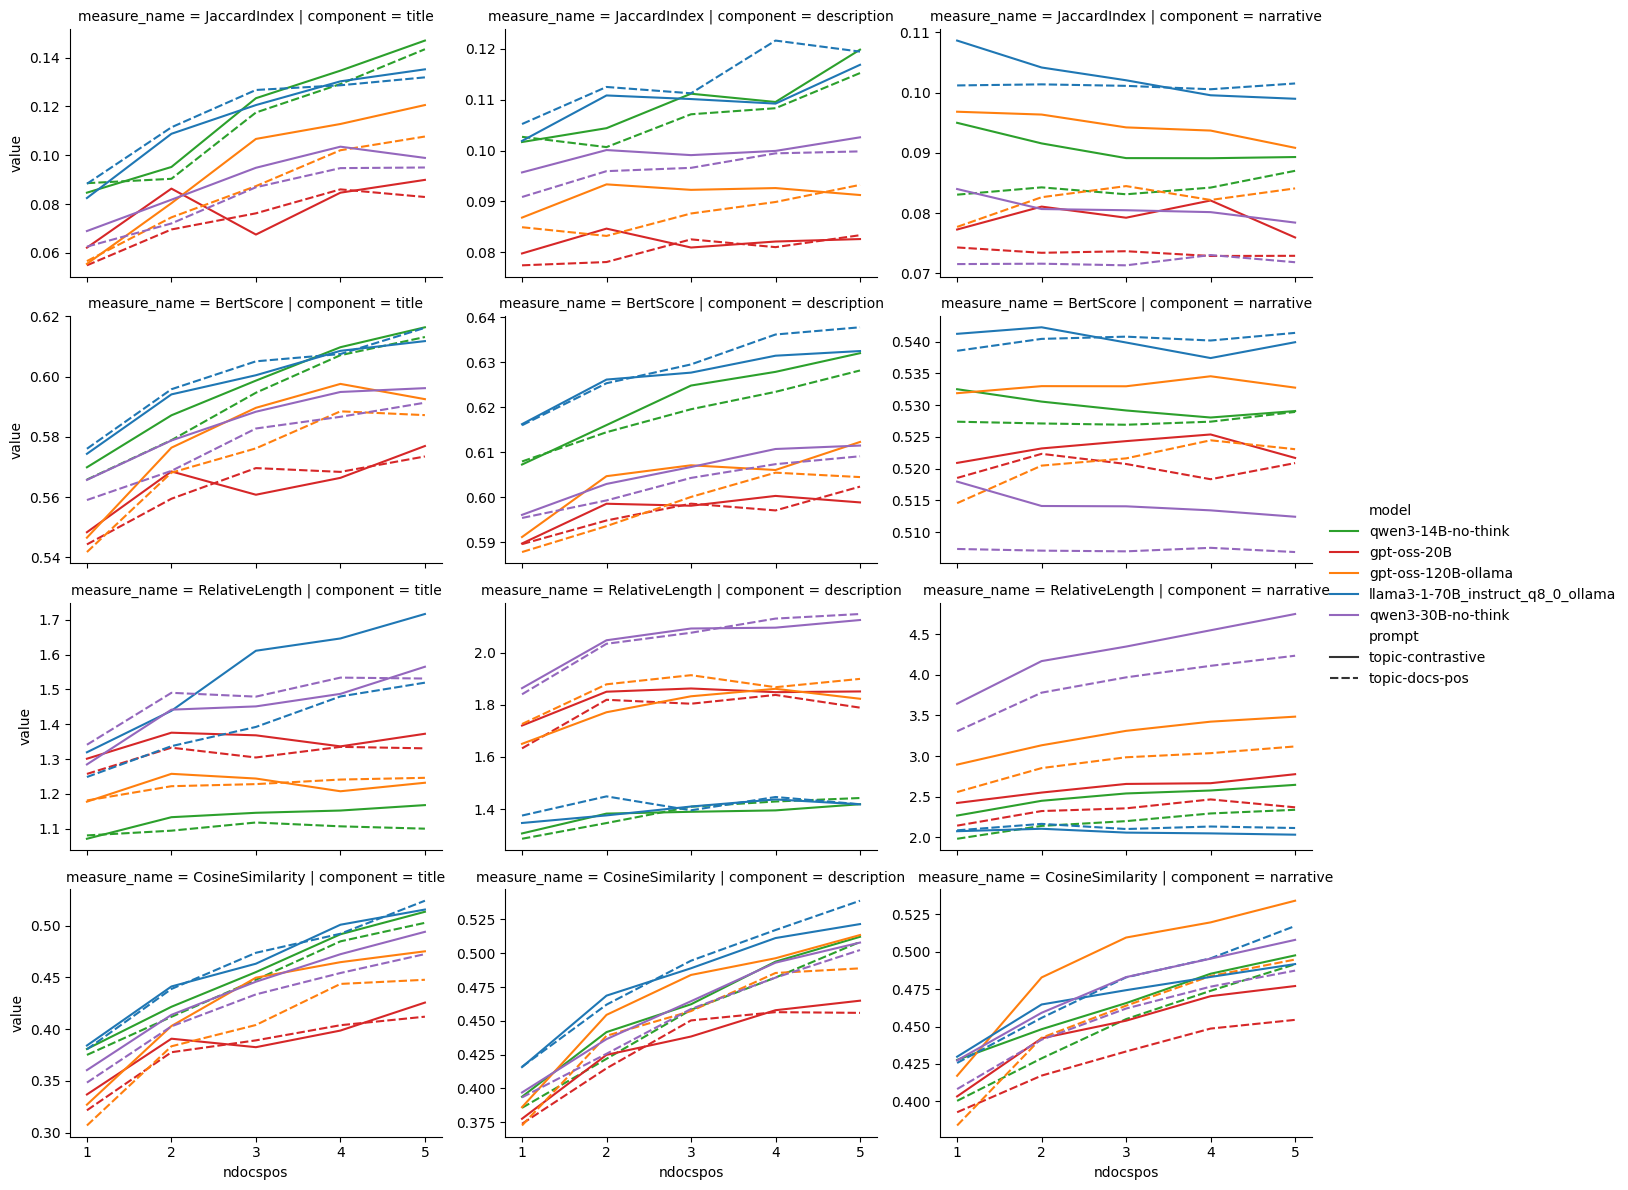

In [51]:
g = sns.relplot(
    data=df[df["prompt"].isin(["topic-contrastive", "topic-docs-pos"])],
    x="ndocspos",
    y="value",
    hue="model",
    style="prompt",
    row="measure_name",
    col_order=col_order,
    col="component",
    kind="line",
    height=3,
    aspect=1.5,
    palette=model_colors,
    facet_kws={"sharey": False},
)

In [ ]:
# Table
# Context / similarity lineplot
# Nqueries, ndocs vs similarity Heatmap
# examples